In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, skew

In [209]:
train_df = pd.read_csv(r'../train.csv')
test_df = pd.read_csv(r'../test.csv')

In [210]:
train_df.shape, test_df.shape

((1460, 81), (1459, 80))

#### EDA

##### Drop the id column

In [211]:
train_df_ID = train_df.loc[:, 'Id']
test_df_ID = test_df.loc[:, 'Id']

In [212]:
train_df.drop(columns='Id', inplace=True)
test_df.drop(columns='Id', inplace=True)

In [213]:
train_df.shape, test_df.shape

((1460, 80), (1459, 79))

##### Remove the outliers in GrLivArea

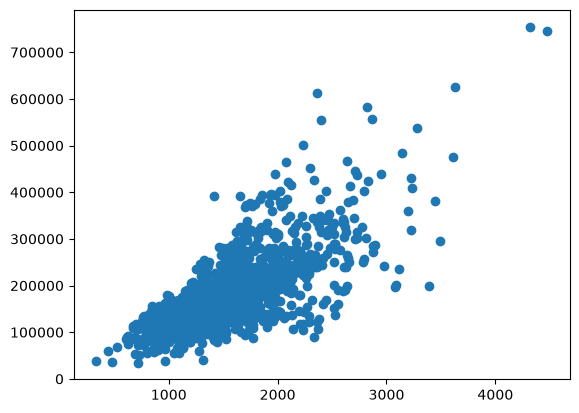

In [214]:
train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)

plt.scatter(train_df['GrLivArea'], train_df['SalePrice'])
plt.show()

##### Analysis of SalePrice

<Axes: xlabel='SalePrice', ylabel='Count'>

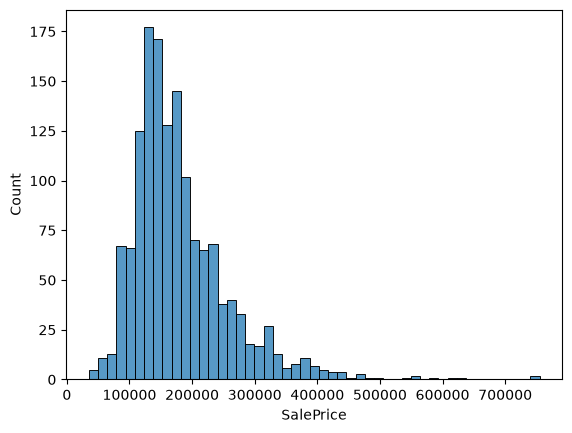

In [13]:
sns.histplot(train_df['SalePrice'])

Target is right skewed.

In [215]:
mu, sigma = norm.fit(train_df['SalePrice'])
mu, sigma

(np.float64(180932.91906721535), np.float64(79467.78892987774))

For SalePrice:  
Estimated Average(mu) -> 180932.91906721535  
Estimated Spread(sigma) -> 79467.78892987774

Transforming the target, SalePrice to a normal distribution

12.024015155682552 0.3995757283645756


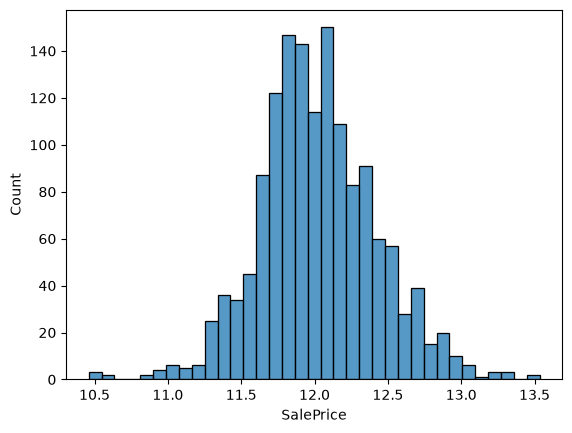

In [216]:
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

mu, sigma = norm.fit(train_df.SalePrice)
print(mu, sigma)

sns.histplot(train_df.SalePrice)
plt.show()

Data appears to be normally distributed.  
Estimated mean is 12.02, Estimated spread is 0.399

#### Feature Engineering

##### Concatenate the two datasets

In [217]:
ntrain = train_df.shape[0]
ntest = test_df.shape[0]

train_target = train_df.SalePrice

all_data = pd.concat((train_df, test_df)).reset_index(drop=True)
all_data.drop(columns='SalePrice', inplace=True)
all_data.shape

(2917, 79)

##### Missing data

In [220]:
def check_missing():
  all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
  all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
  missing_data = pd.DataFrame({'Missing Ratio' :all_data_na})
  return missing_data

check_missing().head(20)

,Missing Ratio
PoolQC,99.691464
MiscFeature,96.400411
Alley,93.212204
Fence,80.425094
MasVnrType,60.541652
FireplaceQu,48.680151
LotFrontage,16.660953
GarageQual,5.450806
GarageYrBlt,5.450806
GarageCond,5.450806


##### Imputting missing values

In [221]:
all_data["PoolQC"] = all_data["PoolQC"].fillna("None")
all_data["MiscFeature"] = all_data["MiscFeature"].fillna("None")
all_data["Alley"] = all_data["Alley"].fillna("None")
all_data["Fence"] = all_data["Fence"].fillna("None")
all_data["FireplaceQu"] = all_data["FireplaceQu"].fillna("None")

In [222]:
#Group by neighborhood and fill in missing value by the median LotFrontage of all the neighborhood
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))

In [223]:
for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'):
    all_data[col] = all_data[col].fillna('None')

for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    all_data[col] = all_data[col].fillna('None')

all_data["MasVnrType"] = all_data["MasVnrType"].fillna("None")

In [224]:
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    all_data[col] = all_data[col].fillna(0)

for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    all_data[col] = all_data[col].fillna(0)

all_data["MasVnrArea"] = all_data["MasVnrArea"].fillna(0)

In [225]:
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])
all_data["Functional"] = all_data["Functional"].fillna("Typ")
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])
all_data['MSSubClass'] = all_data['MSSubClass'].fillna("None")

Utilities : For this categorical feature all records are "AllPub", except for one "NoSeWa" and 2 NA . Since the house with 'NoSewa' is in the training set, this feature won't help in predictive modelling. We can then safely remove it.

In [226]:
all_data = all_data.drop(['Utilities'], axis=1)

In [227]:
check_missing()

,Missing Ratio


##### Transforming numerical features that are categorical

In [228]:
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)

all_data['OverallCond'] = all_data['OverallCond'].astype(str)

all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

##### Label Encoding Categorical Variables

In [229]:
from sklearn.preprocessing import LabelEncoder
cols = (
  'FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
  'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1', 
  'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 'GarageFinish', 'LandSlope',
  'LotShape', 'PavedDrive', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 
  'YrSold', 'MoSold'
)

for c in cols:
    lbl = LabelEncoder() 
    lbl.fit(list(all_data[c].values)) 
    all_data[c] = lbl.transform(list(all_data[c].values))

all_data[list(cols)]

,FireplaceQu,BsmtQual,BsmtCond,GarageQual,GarageCond,ExterQual,ExterCond,HeatingQC,PoolQC,KitchenQual,...,LandSlope,LotShape,PavedDrive,Street,Alley,CentralAir,MSSubClass,OverallCond,YrSold,MoSold
0,3,2,4,5,5,2,4,0,3,2,...,0,3,2,1,1,1,10,4,2,4
1,5,2,4,5,5,3,4,0,3,3,...,0,3,2,1,1,1,5,7,1,7
2,5,2,4,5,5,2,4,0,3,2,...,0,0,2,1,1,1,10,4,2,11
3,2,4,1,5,5,3,4,2,3,2,...,0,0,2,1,1,1,11,4,0,4
4,5,2,4,5,5,2,4,0,3,2,...,0,0,2,1,1,1,10,4,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,3,4,4,3,3,3,4,2,3,3,...,0,3,2,1,1,1,2,6,0,8
2913,3,4,4,5,5,3,4,4,3,3,...,0,3,2,1,1,1,2,4,0,6
2914,5,4,4,5,5,3,4,0,3,3,...,0,3,2,1,1,1,5,6,0,11
2915,3,2,4,3,3,3,4,4,3,3,...,0,3,2,1,1,1,14,4,0,9


Add total SF 

In [230]:
# Adding total sqfootage feature 
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

Check Features Skewness

In [232]:
numeric_feats = all_data.select_dtypes(exclude='str').dtypes.index
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness.head(10)

,Skew
MiscVal,21.939672
PoolArea,17.688664
LotArea,13.109495
LowQualFinSF,12.084539
3SsnPorch,11.372080
LandSlope,4.973254
KitchenAbvGr,4.300550
BsmtFinSF2,4.144503
EnclosedPorch,4.002344
ScreenPorch,3.945101


In [233]:
len(numeric_feats)

59

##### Carry out Box Cox Transformation on highly skewed features

In [235]:
from scipy.special import boxcox1p

In [ ]:
skewed_features = skewness.index
lam = 0.15
for feat in skewed_features:
    all_data[feat] = boxcox1p(all_data[feat], lam)

skewed_features

Index(['MiscVal', 'PoolArea', 'LotArea', 'LowQualFinSF', '3SsnPorch',
       'LandSlope', 'KitchenAbvGr', 'BsmtFinSF2', 'EnclosedPorch',
       'ScreenPorch', 'BsmtHalfBath', 'MasVnrArea', 'OpenPorchSF',
       'WoodDeckSF', '1stFlrSF', 'LotFrontage', 'GrLivArea', 'TotalSF',
       'BsmtFinSF1', 'BsmtUnfSF', '2ndFlrSF', 'TotRmsAbvGrd', 'Fireplaces',
       'HalfBath', 'TotalBsmtSF', 'BsmtFullBath', 'OverallCond', 'HeatingQC',
       'FireplaceQu', 'BedroomAbvGr', 'GarageArea', 'OverallQual', 'FullBath',
       'MSSubClass', 'YrSold', 'BsmtFinType1', 'GarageCars', 'YearRemodAdd',
       'BsmtQual', 'YearBuilt', 'GarageFinish', 'LotShape', 'MoSold', 'Alley',
       'BsmtExposure', 'KitchenQual', 'ExterQual', 'Fence', 'ExterCond',
       'BsmtCond', 'PavedDrive', 'BsmtFinType2', 'GarageQual', 'CentralAir',
       'GarageCond', 'GarageYrBlt', 'Functional', 'Street', 'PoolQC'],
      dtype='str')

In [237]:
all_data.shape

(2917, 79)

##### Encode categorical features(One-Hot encoding values through dummies)

In [239]:
all_data = pd.get_dummies(all_data, dtype=int)
all_data.shape

(2917, 220)

#### Get preprocessed train and test sets

In [240]:
train = all_data[:ntrain]
test = all_data[ntrain:]

#### Modelling

In [242]:
from xgboost import XGBRegressor
from load_datasets import split_train_evaluate, create_submission_file
from sklearn.metrics import root_mean_squared_log_error

In [243]:
xgb = XGBRegressor(
  subsample=0.6,
  n_estimators=500,
  min_child_weight=5,
  max_depth=5,
  learning_rate=0.04
)

In [261]:
xgb_model, train_score, val_score = split_train_evaluate(xgb, train, train_target)

Training Loss: 0.002342789978628654
Validation Loss: 0.009325817398836773


In [124]:
xgb_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [258]:
xgb_model.fit(train, train_target)
xgb_train_preds = xgb_model.predict(train)
xgb_test_preds = np.expm1(xgb_model.predict(test))
root_mean_squared_log_error(train_target, xgb_train_preds)

0.002861289867408311

In [259]:
xgb_test_preds

array([126933.766, 159218.77 , 187964.62 , ..., 157993.42 , 116467.01 ,
       215131.19 ], shape=(1459,), dtype=float32)

In [267]:
create_submission_file(xgb_test_preds2, 'xgb_skewed_num_mod')

        Id      SalePrice
0     1461  128488.476562
1     1462  161046.906250
2     1463  186443.703125
3     1464  188167.109375
4     1465  189473.359375
...    ...            ...
1454  2915   75582.273438
1455  2916   81480.804688
1456  2917  164143.437500
1457  2918  119245.679688
1458  2919  213902.890625

[1459 rows x 2 columns]
